# **Exploration Data Analysis - Khám phá dữ liệu**
Trong notebooks này, chúng tôi sẽ tập trung tìm hiểu đặc điểm và xử lý tập dữ liệu `sales.csv` riêng:
- Kiểm tra tổng quan dữ liệu
- Kiểm tra tính toàn vẹn dữ liệu
- Xử lý, làm sạch dữ liệu
- Trực quan hóa dữ liệu

**Mục tiêu**: Xử lý, làm sạch và xác định rõ đặc điểm của tập dữ liệu `sales.csv` trước khi đi vào huấn luyện mô hình

**Mục lục**:
1. [Thiết lập và cài đặt](#1)
2. [Tổng quan dữ liệu](#2)
3. [Trực quan hóa dữ liệu](#3)

<a id="1"></a>

## 1. Thiết lập và cài đặt
Nhập các thư viện cần thiết và kết nối database `datathon.duckdb`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import sys, os

sys.path.append(os.path.abspath('..'))
from src.get_data import get_connection

In [2]:
# Kiểm tra kết nối
conn = get_connection()

[OKE] Kết nối thành công tới database tại D:\datathon\vimchanhxa-datathon\data\database\datathon.duckdb


In [3]:
sql = 'SELECT * FROM sales'
df_sales = conn.execute(sql).df()
df_sales.head()

,date,revenue,cogs
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


## 2. Đặc điểm dữ liệu

In [4]:
df_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   date     3833 non-null   datetime64[us]
 1   revenue  3833 non-null   float64       
 2   cogs     3833 non-null   float64       
dtypes: datetime64[us](1), float64(2)
memory usage: 90.0 KB


In [5]:
df_sales.describe()

,date,revenue,cogs
count,3833,3.833000e+03,3.833000e+03
mean,2017-10-02 00:00:00,4.286584e+06,3.695134e+06
min,2012-07-04 00:00:00,2.798139e+05,2.365763e+05
25%,2015-02-17 00:00:00,2.471089e+06,2.150580e+06
50%,2017-10-02 00:00:00,3.647304e+06,3.161113e+06
75%,2020-05-17 00:00:00,5.350877e+06,4.637294e+06
max,2022-12-31 00:00:00,2.090527e+07,1.653586e+07
std,NaN,2.624840e+06,2.219789e+06


In [6]:
print(f"Thời gian bắt đầu: {df_sales['date'][0]}")
print(f"Thời gian kết thúc: {df_sales['date'].iloc[-1]}")
print(f"Khoảng thời gian: {len(df_sales)} ngày")
print(f"Bước thời gian: {df_sales['date'][1] - df_sales['date'][0]}")

Thời gian bắt đầu: 2012-07-04 00:00:00
Thời gian kết thúc: 2022-12-31 00:00:00
Khoảng thời gian: 3833 ngày
Bước thời gian: 1 days 00:00:00


Như vậy, ta được biết một vài đặc điểm của dữ liệu ở bảng `sales` gồm có
- Cột `date` bắt đầu từ ngày **2012-07-04** -> **2022-12-31**
- Mỗi dòng là một ngày, tổng là 3833 ngày
- Cột `revenue`: thông tin và doanh thu của mỗi ngày
- Cột `cogs`: thông tin về giá vốn của ngày đó

Chính vì đây là bảng dữ liệu theo chuỗi thời gian, vì vậy việc trực quan hóa dữ liệu để thấy được tính chu kỳ là vô cùng cần thiết

## 3. Trực quan hóa dữ liệu

### 3.1 Toàn bộ giai đoạn (2012 - 2022)

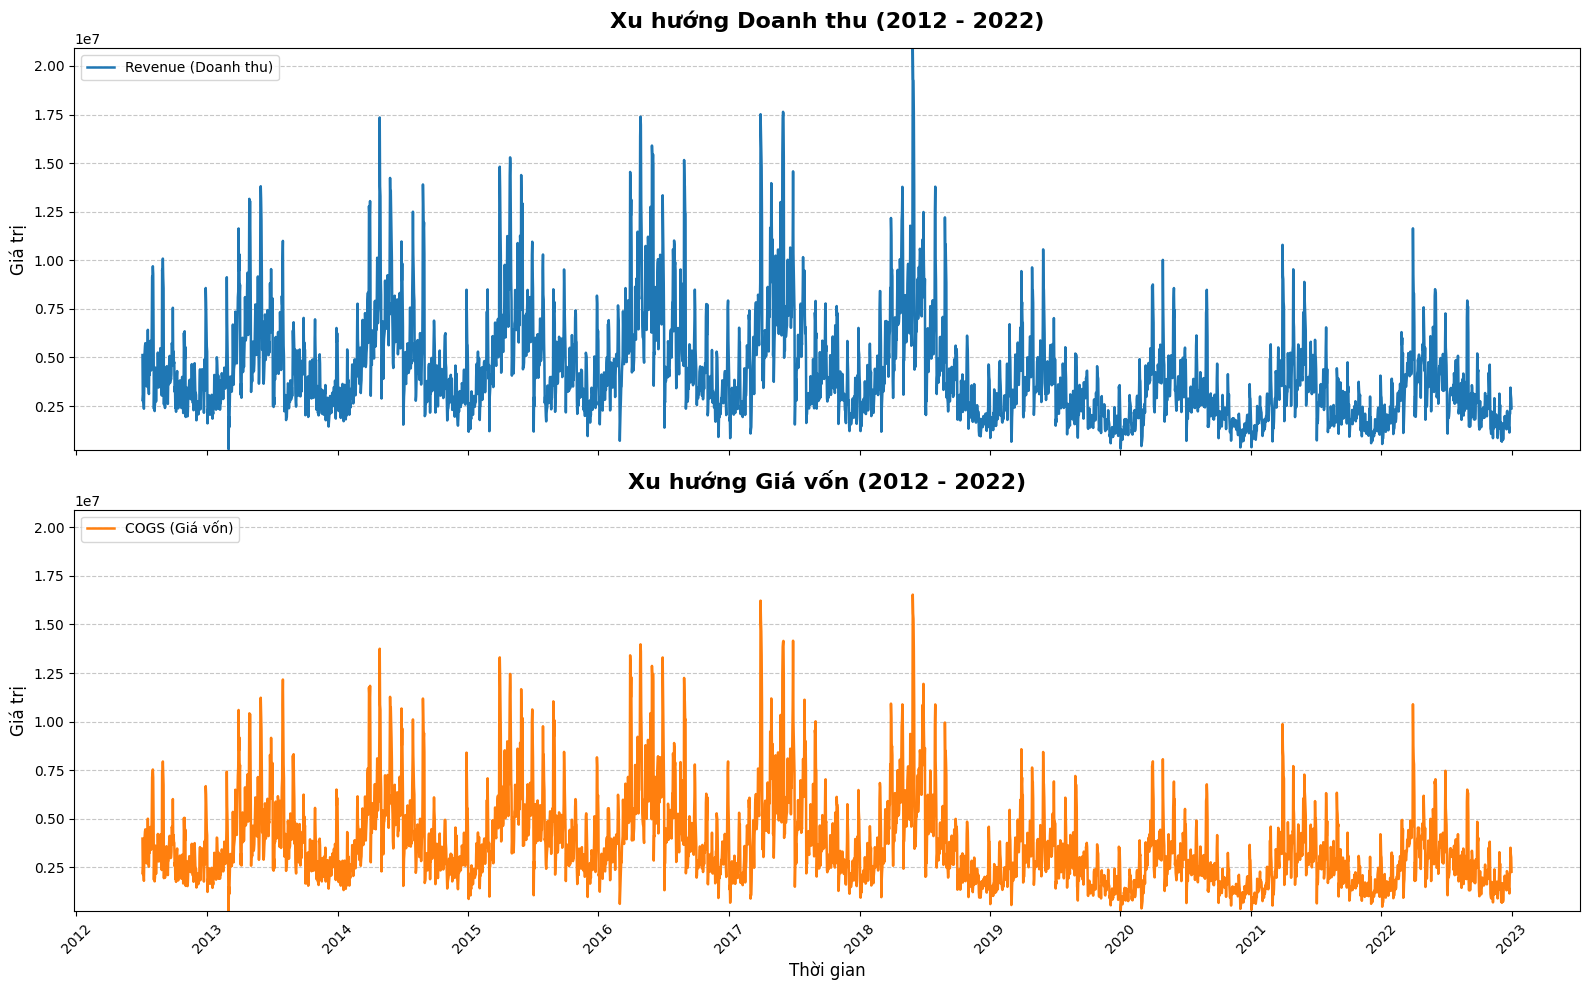

In [7]:
# Trực quan hóa dữ liệu theo chuỗi thời gian
# Xác định min/max chung cho trục Y
y_min = min(df_sales['revenue'].min(), df_sales['cogs'].min())
y_max = max(df_sales['revenue'].max(), df_sales['cogs'].max())
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# revenue
axes[0].plot(
    df_sales['date'],
    df_sales['revenue'],
    color='#1f77b4',
    linewidth=1.8,
    label='Revenue (Doanh thu)'
)

axes[0].set_title(
    'Xu hướng Doanh thu (2012 - 2022)',
    fontsize=16,
    fontweight='bold',
    pad=15
)

axes[0].set_ylabel('Giá trị', fontsize=12)
axes[0].set_ylim(y_min, y_max)   # Trục Y giống nhau
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].legend(loc='upper left')

# cogs
axes[1].plot(
    df_sales['date'],
    df_sales['cogs'],
    color='#ff7f0e',
    linewidth=1.8,
    label='COGS (Giá vốn)'
)

axes[1].set_title(
    'Xu hướng Giá vốn (2012 - 2022)',
    fontsize=16,
    fontweight='bold',
    pad=15
)

axes[1].set_ylabel('Giá trị', fontsize=12)
axes[1].set_xlabel('Thời gian', fontsize=12)
axes[1].set_ylim(y_min, y_max)   # Trục Y giống nhau
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].legend(loc='upper left')

axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Qua biểu đồ ta có thể chắc chắn rằng dữ liệu có tính mùa vụ qua các năm, khi mà tầm giai đoạn từ đầu năm đến cuối năm doanh thu của doanh nghiệp đang được tăng mạnh, rồi từ giữa năm đến cuối năm thì doanh thu lại xuống dốc, và chu kỳ cứ lặp đi lặp lại. Ngoài ra trước 2019 doanh nghiệp lại có doanh thu rất cao, còn từ sau 2019 thì doanh thu đã giảm đi đáng kể.

Câu hỏi đặt ra là:
- Tại sao doanh thu của doanh nghiệp lại tăng cao vào giữa tháng ?
- Tại sao doanh thu lại thấp ở đầu năm và cuối năm ?
- Liệu doanh thu của doanh nghiệp còn chu kỳ ngắn không ?

Phần trăm độ tương quan (Pearson) = 97.60%


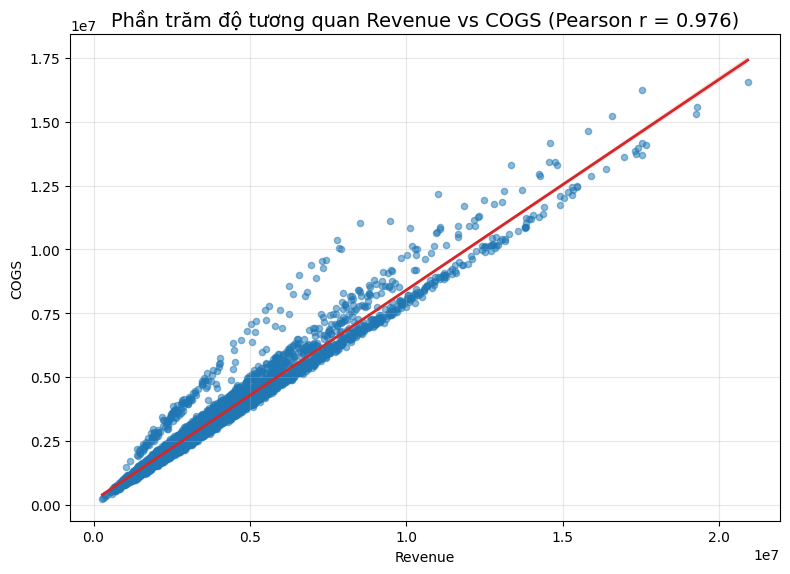

In [8]:
# Tương quan giữa revenue và cogs
corr_value = df_sales['revenue'].corr(df_sales['cogs'])
corr_percent = corr_value * 100
print(f'Phần trăm độ tương quan (Pearson) = {corr_percent:.2f}%')

plt.figure(figsize=(8, 6))
sns.regplot(
    data=df_sales,
    x='revenue',
    y='cogs',
    scatter_kws={'alpha': 0.5, 's': 20},
    line_kws={'color': '#d62728', 'linewidth': 2},
    ci=95,
    color='#1f77b4'
 )
plt.title(f'Phần trăm độ tương quan Revenue vs COGS (Pearson r = {corr_value:.3f})', fontsize=14)
plt.xlabel('Revenue')
plt.ylabel('COGS')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Do `cogs` và `revenue` đang có độ tương quan rất lớn, chúng ta có thể rút ra rằng việc các đợt doanh thu tăng cũng sẽ khiến cho giá vốn tăng, điều này khiến lợi nhuận mà doanh nghiệp thu lại đang chưa được tối ưu.

Ngoài ra, nếu chúng ta sử dụng cogs để cho vào mô hình sẽ khiến mô hình bị overfitting, vì vậy sau đó chúng tôi sẽ quyết định sẽ train mô hình với 2 dữ liệu là `revenue` và `cogs`, đặc biệt `revenue` sẽ được dùng để phân tích và cải thiện mô hình, còn `cogs` sẽ dựa vào đó cộng thêm ràng buộc là `revenue` > `cogs` để dự đoán

**Kiểm tra trend của Revenue và COGS**

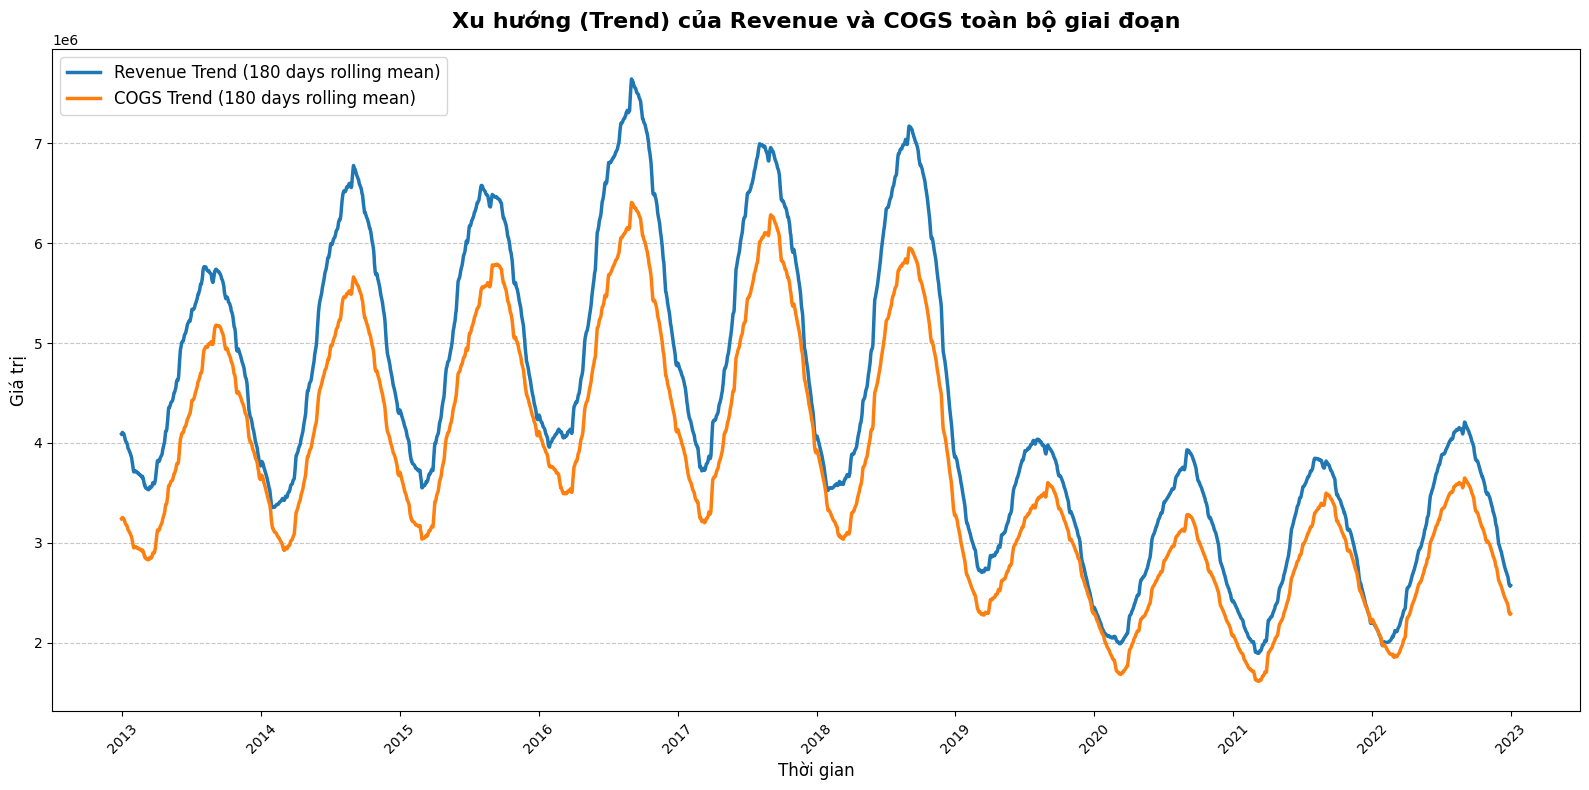

In [9]:
# Trend của Revenue và Cogs toàn bộ giai đoạn

# Sắp xếp dữ liệu theo thời gian để tính rolling mean chính xác
df_sales_sorted = df_sales.sort_values("date")

# Tính Rolling Mean (Trung bình trượt) với cửa sổ 30 ngày (có thể điều chỉnh)
window_size = 180
df_sales_sorted["revenue_trend"] = df_sales_sorted["revenue"].rolling(window=window_size).mean()
df_sales_sorted["cogs_trend"] = df_sales_sorted["cogs"].rolling(window=window_size).mean()

# Vẽ biểu đồ
plt.figure(figsize=(16, 8))

# Vẽ 2 đường trend trên cùng 1 axes
plt.plot(
    df_sales_sorted["date"],
    df_sales_sorted["revenue_trend"],
    color="#1f77b4",
    linewidth=2.5,
    label=f"Revenue Trend ({window_size} days rolling mean)"
)

plt.plot(
    df_sales_sorted["date"],
    df_sales_sorted["cogs_trend"],
    color="#ff7f0e",
    linewidth=2.5,
    label=f"COGS Trend ({window_size} days rolling mean)"
)

plt.title(
    "Xu hướng (Trend) của Revenue và COGS toàn bộ giai đoạn",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Thời gian", fontsize=12)
plt.ylabel("Giá trị", fontsize=12)

# Format trục X
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()


Dễ thấy kể từ sự sụt giảm Revenue và COGS sau giai đoạn 2018-2019, số lãi thu được của doanh nghiệp (Diện tích chênh lệch giữa `Revenue` và `COGS`) giảm đi đáng kể. Vì doanh nghiệp luôn cố gắng thu được lãi cao nhất nên đây có thể không phải chủ ý của doanh nghiệp, mà do nguyên nhân khách quan gây ra

**Giả thuyết:**
- Đối chiếu với tình hình thực tế, 2019-2023 là khoảng thời gian Covid-19 diễn ra mạnh mẽ. Đặc biệt đối với một sàn TMĐT thời trang, nhu cầu lưu trữ loại sản phẩm này sụt giảm do chính sách cách ly xã hội tại một số quốc gia.

**Câu hỏi đặt ra**
- Tuy nhiên, Covid-19 lần đầu xuất hiện vào cuối năm 2019, trong khi `COGS` và `Revenue` của doanh nghiệp đã giảm mạnh từ đầu năm 2019.
- Liệu có thực sự là do Covid-19 không?

Giả thuyết cho sự kiện này sẽ tiếp tục được phân tích sâu hơn tại mục 3.3

### 3.2 Giai đoạn 2012 - 2019:

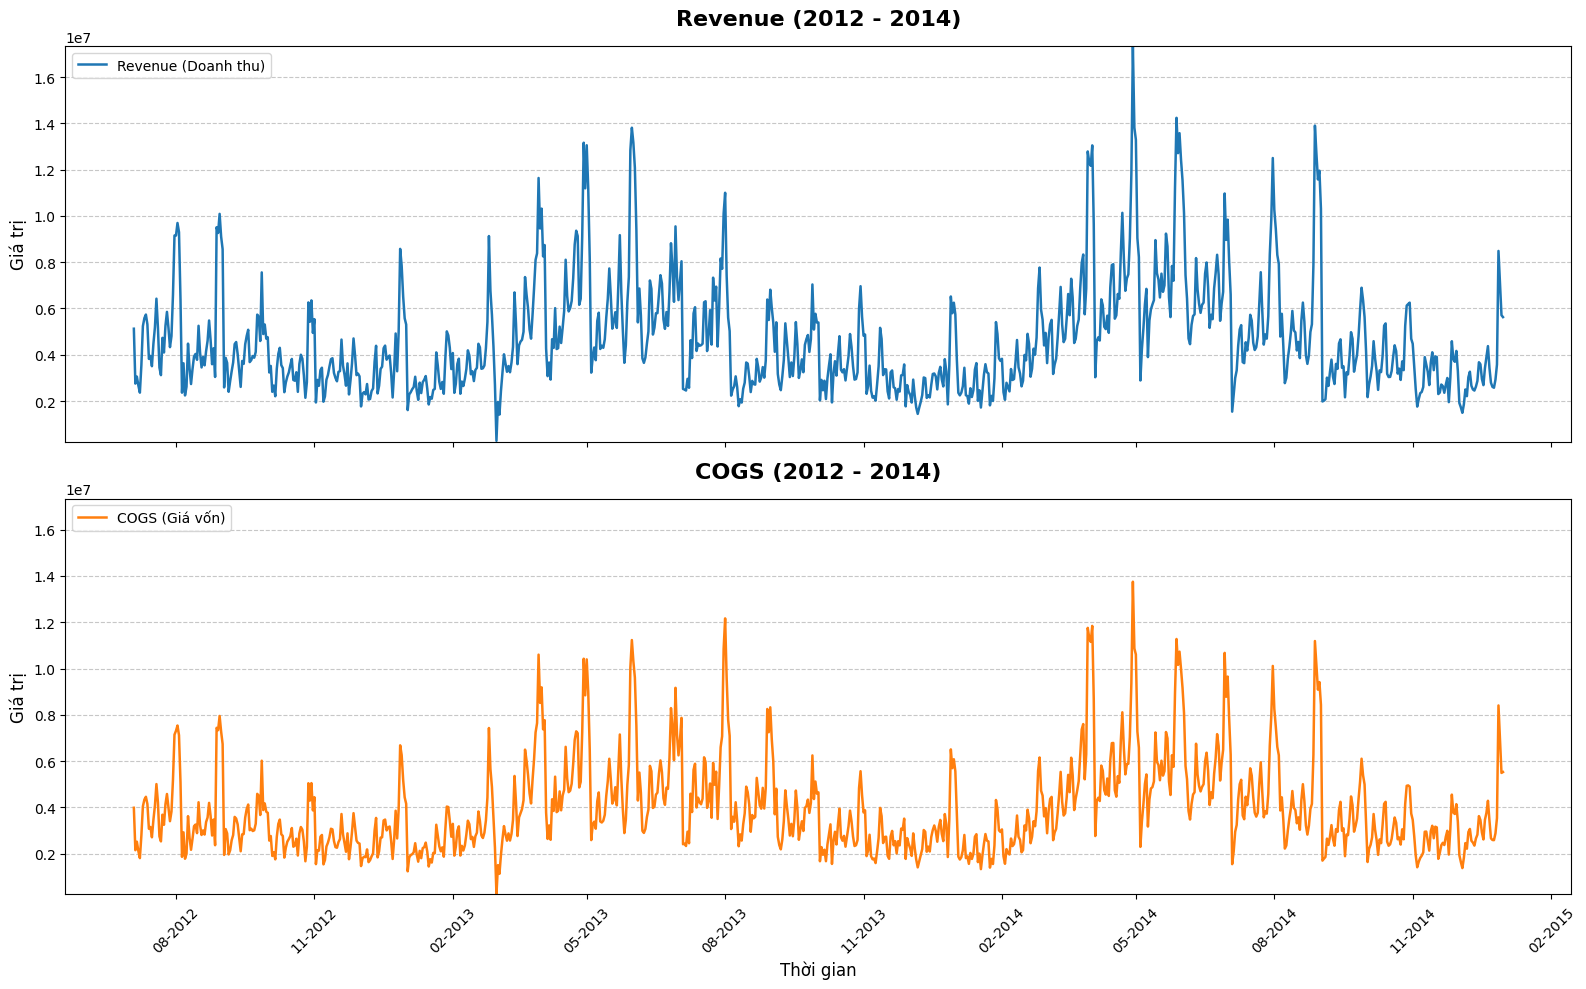

In [10]:
# Trực quan hóa dữ liệu Revenue và Cogs theo chuỗi thời gian 2012-2014

# Lọc dữ liệu giai đoạn 2012-2014
df_2012_2014 = df_sales[(df_sales["date"].dt.year >= 2012) & (df_sales["date"].dt.year <= 2014)]

# Xác định min/max chung cho trục Y
y_min_zoom = min(df_2012_2014["revenue"].min(), df_2012_2014["cogs"].min())
y_max_zoom = max(df_2012_2014["revenue"].max(), df_2012_2014["cogs"].max())
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# revenue
axes[0].plot(
    df_2012_2014["date"],
    df_2012_2014["revenue"],
    color="#1f77b4",
    linewidth=1.8,
    label="Revenue (Doanh thu)"
)

axes[0].set_title(
    "Revenue (2012 - 2014)",
    fontsize=16,
    fontweight="bold",
    pad=15
)

axes[0].set_ylabel("Giá trị", fontsize=12)
axes[0].set_ylim(y_min_zoom, y_max_zoom)
axes[0].grid(axis="y", linestyle="--", alpha=0.7)
axes[0].legend(loc="upper left")

# cogs
axes[1].plot(
    df_2012_2014["date"],
    df_2012_2014["cogs"],
    color="#ff7f0e",
    linewidth=1.8,
    label="COGS (Giá vốn)"
)

axes[1].set_title(
    "COGS (2012 - 2014)",
    fontsize=16,
    fontweight="bold",
    pad=15
)

axes[1].set_ylabel("Giá trị", fontsize=12)
axes[1].set_xlabel("Thời gian", fontsize=12)
axes[1].set_ylim(y_min_zoom, y_max_zoom)
axes[1].grid(axis="y", linestyle="--", alpha=0.7)
axes[1].legend(loc="upper left")

axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%m-%Y"))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


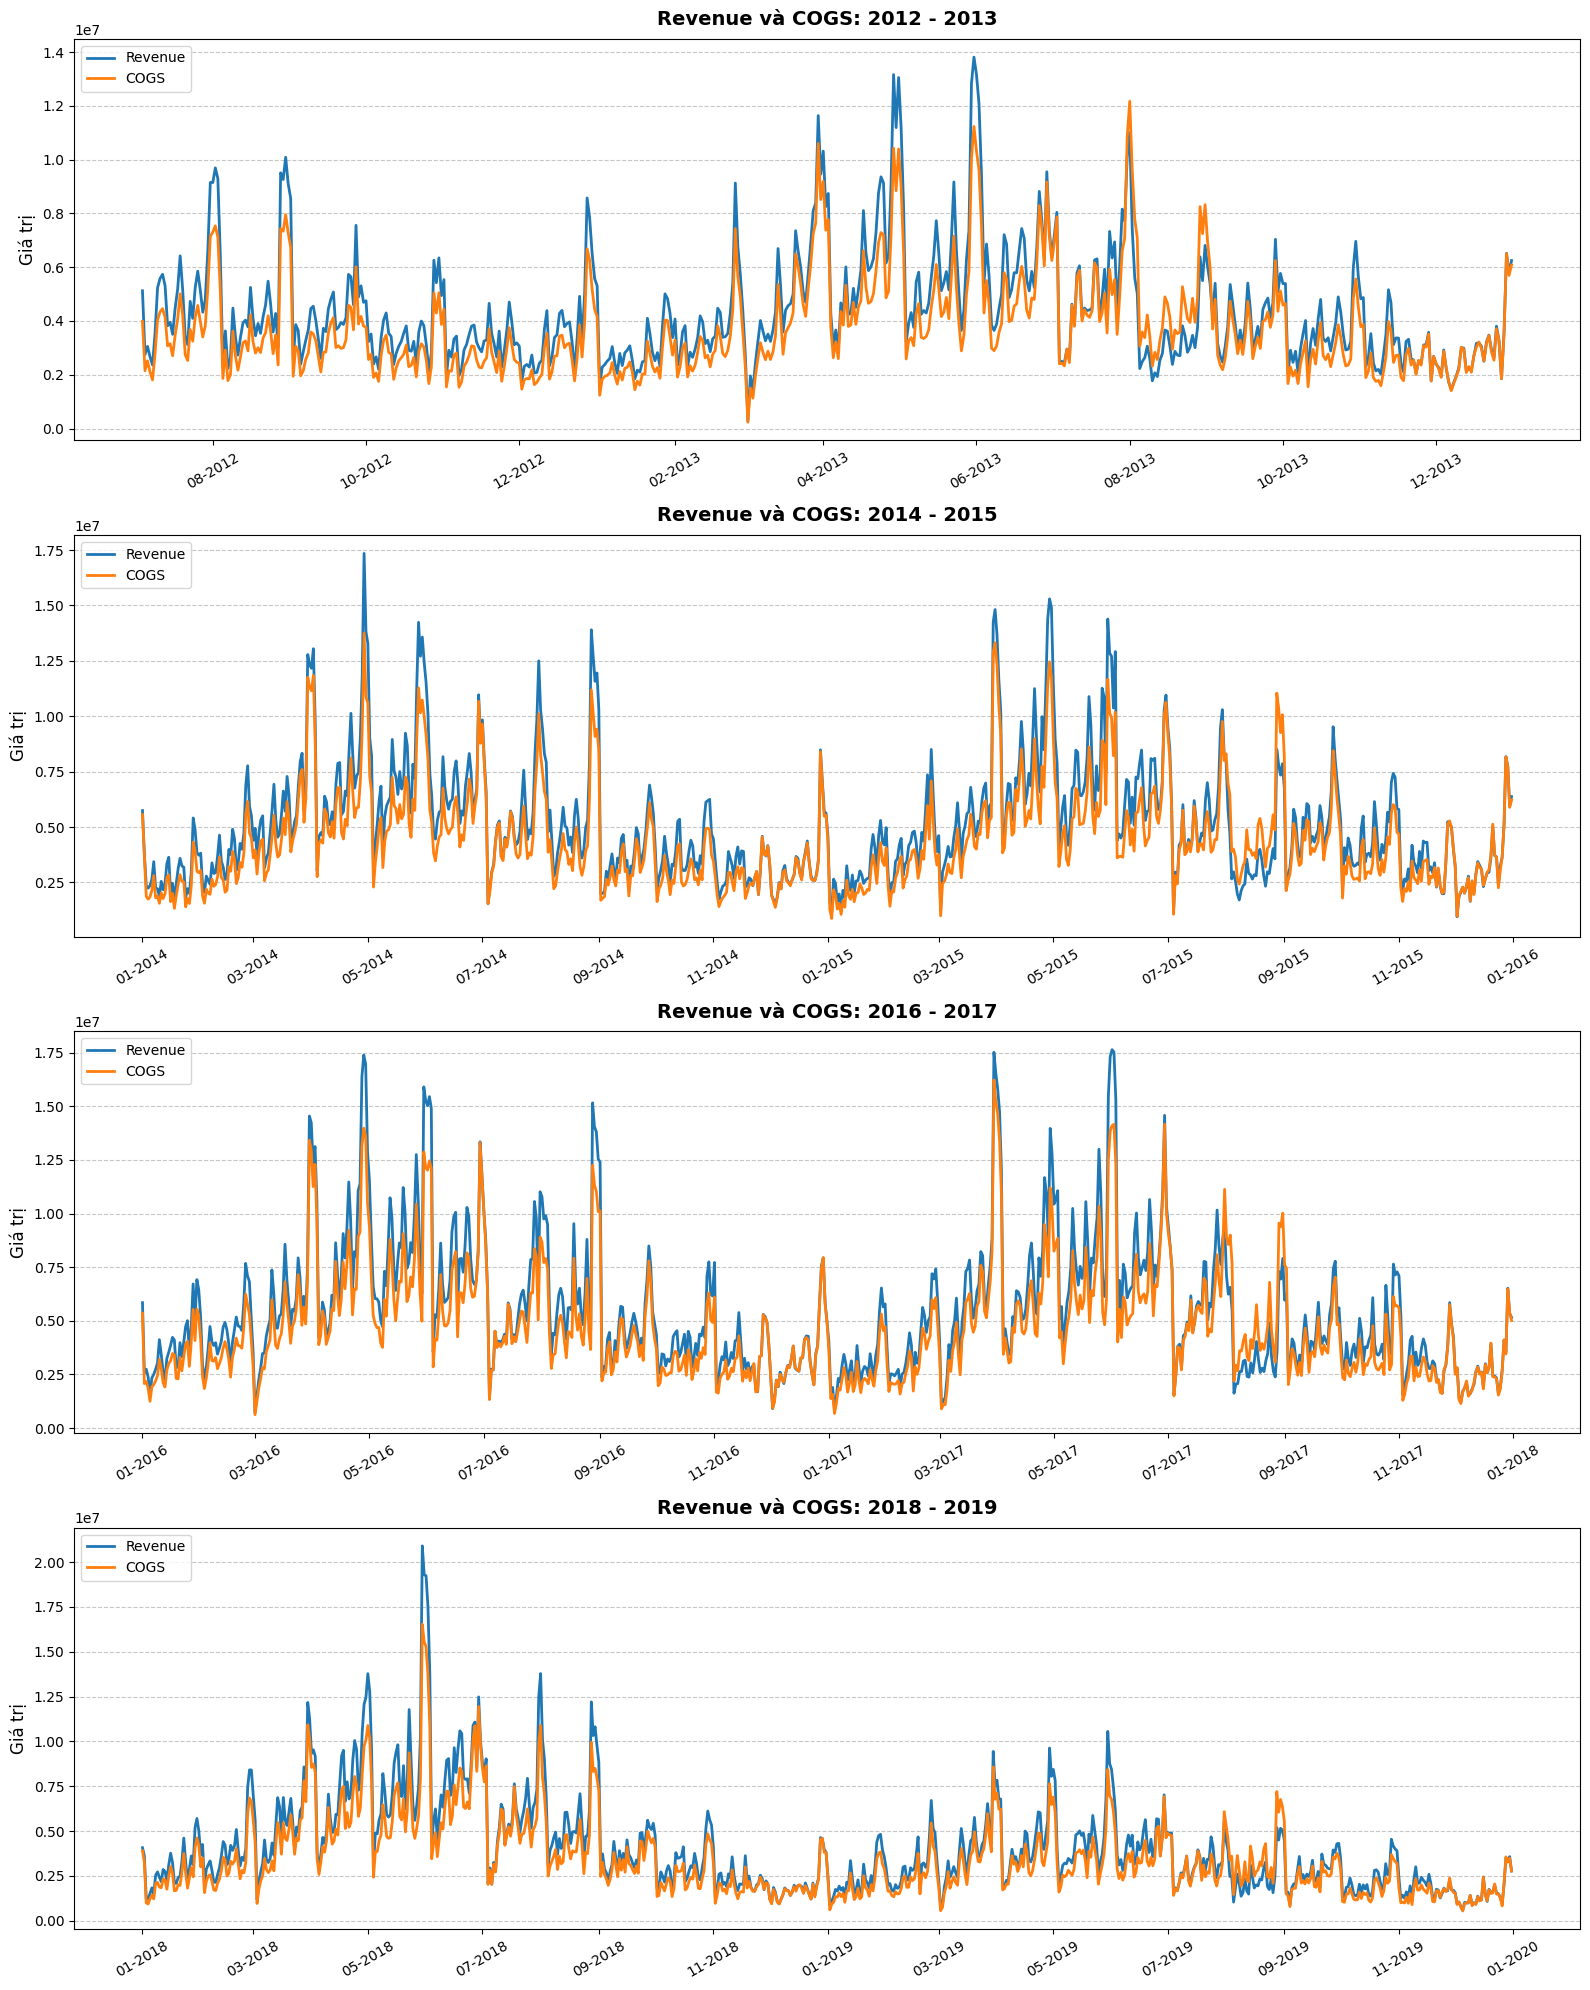

In [ ]:
# Trực quan các dữ liệu theo cặp năm liên tiếp từ 2012 - 2019

years_pairs = [(2012, 2013), (2014, 2015), (2016, 2017), (2018, 2019)]
fig, axes = plt.subplots(4, 1, figsize=(16, 20), sharex=False)

# Đảm bảo cột date có định dạng datetime (nếu chưa có)
if not pd.api.types.is_datetime64_any_dtype(df_sales["date"]):
    df_sales["date"] = pd.to_datetime(df_sales["date"])

for i, (start_year, end_year) in enumerate(years_pairs):
    # Lọc dữ liệu cho 2 năm liên tiếp
    mask = (df_sales["date"].dt.year >= start_year) & (df_sales["date"].dt.year <= end_year)
    df_pair = df_sales[mask].sort_values("date")
    
    # Vẽ line cho Revenue và COGS
    axes[i].plot(df_pair["date"], df_pair["revenue"], color="#1f77b4", linewidth=2, label="Revenue")
    axes[i].plot(df_pair["date"], df_pair["cogs"], color="#ff7f0e", linewidth=2, label="COGS")
    
    # Định dạng subplot
    axes[i].set_title(f"Revenue và COGS: {start_year} - {end_year}", fontsize=14, fontweight="bold", pad=10)
    axes[i].set_ylabel("Giá trị", fontsize=12)
    
    # Format trục X
    axes[i].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter("%m-%Y"))
    axes[i].tick_params(axis="x", rotation=30)
    
    axes[i].grid(axis="y", linestyle="--", alpha=0.7)
    axes[i].legend(loc="upper left")

plt.tight_layout()
plt.show()


**Quan sát:**
- Cứ vào tháng 9 mỗi hai năm một lần kể từ 2013 (Các năm lẻ), doanh nghiệp lại chịu lỗ khoảng 2.5 triệu => Nếu điều này vẫn diễn ra kể từ sau 2019 thì thêm feature `is_odd_year` 
- Trong tháng 12, giá COGS luôn luôn xấp xỉ bằng giá Revenue, doanh nghiệp gần như không sinh lợi nhuận
=> Tương tự với biến `is_Dec`
- Tháng 6 thường xuyên thu được lợi nhuận lớn nhất => Tương tự: `is_Jun`

**Các feature cần tiếp tục kiểm chứng từ giai đoạn 2019 về sau:**

| Feature | Giải thích chi tiết |
| :--- | :--- |
| **`is_odd_year`** | Năm lẻ. |
| **`is_Dec`** | có phải tháng 12 không.|
| **`is_Jun`** | có phải tháng 12 không. |

Nếu từ sau 2019, các đặc điểm này không tiếp tục thì sẽ bị loại bỏ

<a id='1'></a>

## 4. Tính chu kỳ
Sau khi quan sát, chúng tôi nhận thấy là từ 2012 đến 2018, doanh thu có xu hướng tăng qua các năm, nhưng qua 2019 thì doanh thu xụt giảm đi nghiêm trọng nhưng tại bắt đầu tăng trở lại nhẹ qua các năm sau. Chúng tôi sẽ xác định qua những biểu đồ dưới dây

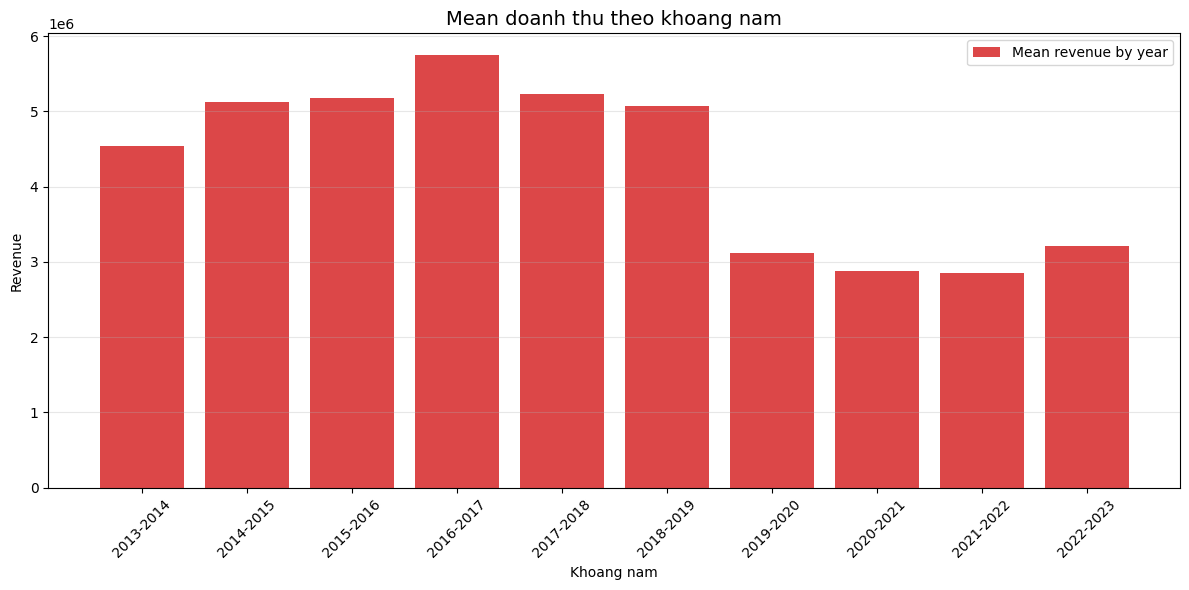

In [12]:
# Doanh thu trung bình theo năm
df_plot = df_sales.copy()
df_plot['date'] = pd.to_datetime(df_plot['date'])
df_plot = df_plot.sort_values('date').set_index('date')

yearly_mean = df_plot['revenue'].resample('YE').mean()
yearly_mean = yearly_mean[yearly_mean.index.year >= 2013]
years = yearly_mean.index.year
year_labels = [f"{y}-{y+1}" for y in years]

plt.figure(figsize=(12, 6))
plt.bar(range(len(yearly_mean)), yearly_mean.values, color='#d62728', alpha=0.85, label='Mean revenue by year')
plt.title('Mean doanh thu theo khoang nam', fontsize=14)
plt.xlabel('Khoang nam')
plt.ylabel('Revenue')
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.xticks(range(len(year_labels)), year_labels, rotation=45)
plt.tight_layout()
plt.show()

Như vậy, ta có thể nhận định rằng doanh thu từ 2013 - 2019, doanh thu có xu hướng tăng triển lên và duy trì ở một mức nhất định, sau đó sụt giảm ở sau 2019, nhưng đến 2022 - 2023 lại bắt đầu tăng lại, có khẳ năng sau đó doanh thu có thể tăng lại. Tuy nhiên vì đây chỉ là lần đầu tiên việc này xảy ra, dẫn đến không có cơ sở nào để nói rằng đây là một chu kỳ.

## 5. Tính mùa vụ
Sau khi xử lý được tính chu kỳ của doanh nghiệp, chúng tôi sẽ kiểm tra thêm tính mùa vụ qua từng khoảng thời gian dưới đây:
- **Year**
- **Month**
- **Week**

### 5.1 Mùa vụ theo Năm

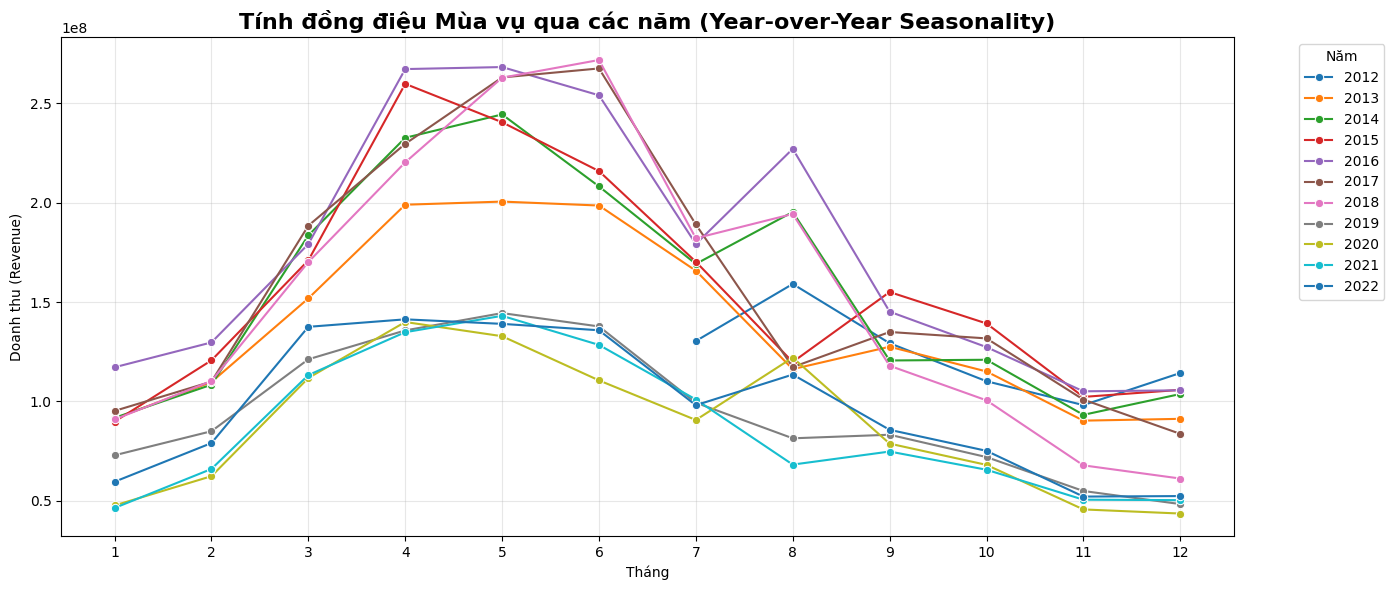

--- PHÂN TÍCH CON SỐ MÙA VỤ ---

1. CHỈ SỐ MÙA VỤ (SEASONAL INDEX) THEO THÁNG:
Tháng 01: Hệ số 0.603 -> Giảm 39.7% so với trung bình năm.
Tháng 02: Hệ số 0.749 -> Giảm 25.1% so với trung bình năm.
Tháng 03: Hệ số 1.185 -> Tăng 18.5% so với trung bình năm.
Tháng 04: Hệ số 1.493 -> Tăng 49.3% so với trung bình năm.
Tháng 05: Hệ số 1.550 -> Tăng 55.0% so với trung bình năm.
Tháng 06: Hệ số 1.463 -> Tăng 46.3% so với trung bình năm.
Tháng 07: Hệ số 1.115 -> Tăng 11.5% so với trung bình năm.
Tháng 08: Hệ số 1.028 -> Tăng 2.8% so với trung bình năm.
Tháng 09: Hệ số 0.868 -> Giảm 13.2% so với trung bình năm.
Tháng 10: Hệ số 0.783 -> Giảm 21.7% so với trung bình năm.
Tháng 11: Hệ số 0.590 -> Giảm 41.0% so với trung bình năm.
Tháng 12: Hệ số 0.574 -> Giảm 42.6% so với trung bình năm.

2. KIỂM ĐỊNH THỐNG KÊ (Kruskal-Wallis Test):
P-value = 0.00000
=> KẾT LUẬN: P-value < 0.05. Tính mùa vụ LÀ CÓ THẬT và cực kỳ rõ rệt (Không phải do ngẫu nhiên).


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

# Giả định bạn đã có df_monthly từ bước trước (đã nén theo tháng)
df_monthly = df_sales.set_index('date').resample('ME')['revenue'].sum().reset_index()

# Thêm cột Năm và Tháng
df_monthly['year'] = df_monthly['date'].dt.year
df_monthly['month'] = df_monthly['date'].dt.month

# ==========================================
# 1. TRỰC QUAN HÓA: MÙA VỤ YEAR-OVER-YEAR (YoY)
# ==========================================
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_monthly, x='month', y='revenue', hue='year', palette='tab10', marker='o', linewidth=1.5)
plt.title('Tính đồng điệu Mùa vụ qua các năm (Year-over-Year Seasonality)', fontsize=16, fontweight='bold')
plt.xlabel('Tháng')
plt.ylabel('Doanh thu (Revenue)')
plt.xticks(range(1, 13))
plt.legend(title='Năm', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==========================================
# 2. TÍNH TOÁN CON SỐ: CHỈ SỐ MÙA VỤ VÀ KIỂM ĐỊNH
# ==========================================
print("--- PHÂN TÍCH CON SỐ MÙA VỤ ---")

# A. Phân rã chuỗi thời gian (Multiplicative Decomposition)
# Dùng Multiplicative vì biên độ mùa vụ thường nở ra/thu lại theo độ lớn của Trend
decomposition = sm.tsa.seasonal_decompose(df_monthly.set_index('date')['revenue'], model='multiplicative', period=12)

# B. Trích xuất Chỉ số mùa vụ (Seasonal Index) của 12 tháng
seasonal_index = decomposition.seasonal[:12].reset_index()
seasonal_index['month'] = seasonal_index['date'].dt.month
seasonal_index = seasonal_index[['month', 'seasonal']].sort_values('month')
seasonal_index['seasonal_pct'] = (seasonal_index['seasonal'] - 1) * 100 # Chuyển thành % tăng/giảm

print("\n1. CHỈ SỐ MÙA VỤ (SEASONAL INDEX) THEO THÁNG:")
for index, row in seasonal_index.iterrows():
    status = "Tăng" if row['seasonal_pct'] > 0 else "Giảm"
    print(f"Tháng {int(row['month']):02d}: Hệ số {row['seasonal']:.3f} -> {status} {abs(row['seasonal_pct']):.1f}% so với trung bình năm.")

# C. Kiểm định Thống kê (Kruskal-Wallis H-test)
# Đặt câu hỏi: "Sự khác biệt doanh thu giữa các tháng có thực sự ý nghĩa về mặt thống kê không?"
# Nhóm doanh thu theo từng tháng
monthly_groups = [group['revenue'].values for name, group in df_monthly.groupby('month')]

# Thực hiện kiểm định Kruskal-Wallis (Robust hơn ANOVA cho dữ liệu không phân phối chuẩn)
stat, p_value = stats.kruskal(*monthly_groups)

print("\n2. KIỂM ĐỊNH THỐNG KÊ (Kruskal-Wallis Test):")
print(f"P-value = {p_value:.5f}")
if p_value < 0.05:
    print("=> KẾT LUẬN: P-value < 0.05. Tính mùa vụ LÀ CÓ THẬT và cực kỳ rõ rệt (Không phải do ngẫu nhiên).")
else:
    print("=> KẾT LUẬN: P-value >= 0.05. Biến động giữa các tháng có thể do ngẫu nhiên, tính mùa vụ yếu.")

**Nhận xét**:

Như vậy ta có thể thấy được tính mùa vụ theo năm, khi mà từ đầu tháng thấp và tăng dần, đạt cao nhất vào các tháng giữa năm, rồi lại đi xuống ở những tháng cuối. Đồng thời giá trị kiểm định `p-value < 0.05` là một bằng chứngg rõ ràng rằng dữ liệu đang có tính mùa vụ theo năm.

Một vài features tốt:
- `revenue_lag_364`: Dữ liệu của ngày này năm trước
- `revenue_rolling_mean_28`: Trung bình 4 tuần gần nhất
- `revenue_rolling_mean_90`: Trung bình 1 quý gần nhất
- `momentum_ratio`: Tỷ lệ đà tăng trưởng ( `revenue_rolling_mean_28` / `revenue_rolling_mean_90` )
- `month`: Từ tháng 1 - 12
- `seasonal_index`: Hệ số mùa vụ ( được lấy từ bảng dữ liệu trên )
- `is_peak_season`: Cờ mùa cao điểm ( Từ tháng 3 đến tháng 8)

### 5.3 Mùa vụ theo Tháng

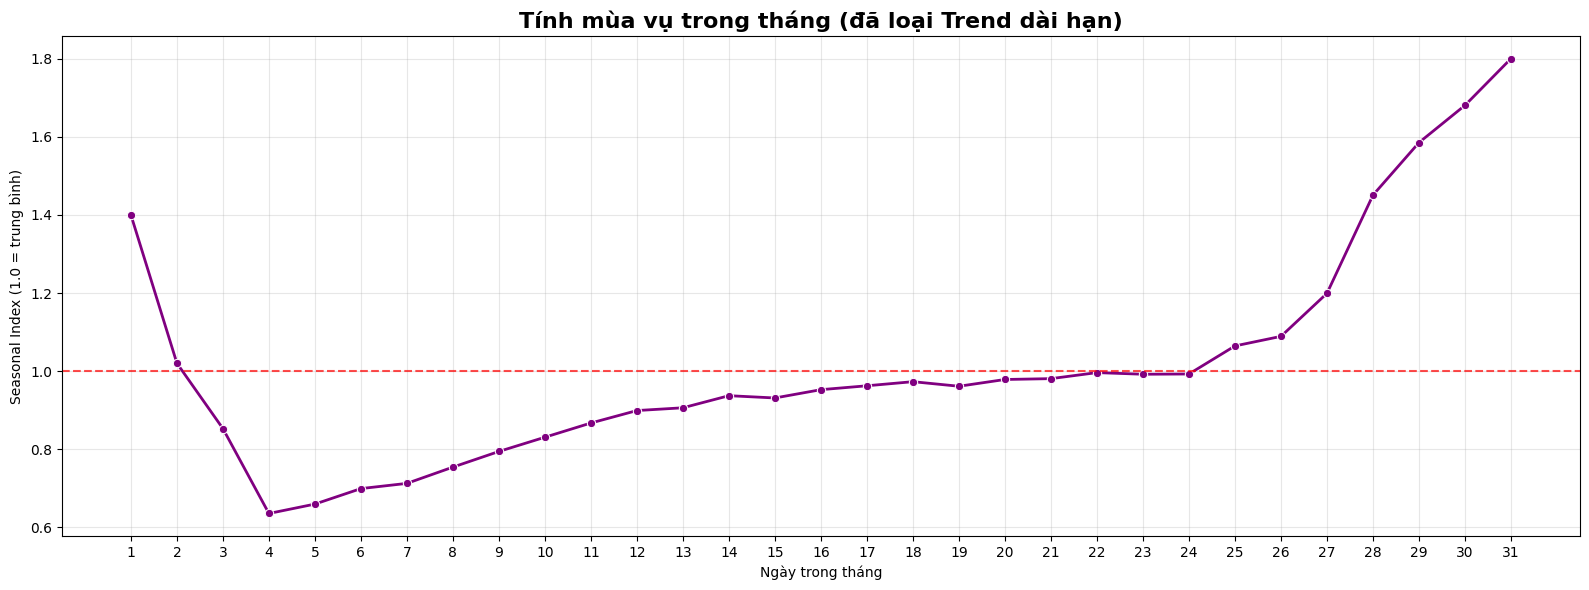

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ==================================================
# KIỂM TRA TÍNH MÙA VỤ TRONG THÁNG (INTRA-MONTH)
# Phiên bản nâng cấp chuẩn EDA / Forecasting
# ==================================================

# Copy dữ liệu để tránh sửa gốc
df = df_sales.copy()

# --------------------------------------------------
# 1. Chuẩn hóa dữ liệu
# --------------------------------------------------
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Tạo cột ngày trong tháng
df['day_of_month'] = df['date'].dt.day

# --------------------------------------------------
# 2. Xử lý trend dài hạn (Detrend)
# Rolling mean 30 ngày
# --------------------------------------------------
df['trend_30'] = df['revenue'].rolling(
    window=30,
    min_periods=7,
).mean()

# Revenue đã loại trend
df['adj_revenue'] = df['revenue'] / df['trend_30']

# Xóa NA đầu chuỗi
df = df.dropna(subset=['adj_revenue'])

# --------------------------------------------------
# 3. Tính thống kê theo ngày trong tháng
# --------------------------------------------------
daily_stats = df.groupby('day_of_month').agg(
    mean_adj=('adj_revenue', 'mean'),
    median_adj=('adj_revenue', 'median'),
    std_adj=('adj_revenue', 'std'),
    n_obs=('adj_revenue', 'count')
).reset_index()

# Seasonal index (% so với trung bình = 1.0)
daily_stats['seasonal_pct'] = (daily_stats['mean_adj'] - 1) * 100

# --------------------------------------------------
# 4. VISUALIZATION #1 - Line Plot
# --------------------------------------------------
plt.figure(figsize=(16,6))

sns.lineplot(
    data=daily_stats,
    x='day_of_month',
    y='mean_adj',
    marker='o',
    linewidth=2,
    color='purple'
)

plt.axhline(1.0, linestyle='--', color='red', alpha=0.7)

plt.title(
    'Tính mùa vụ trong tháng (đã loại Trend dài hạn)',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Ngày trong tháng')
plt.ylabel('Seasonal Index (1.0 = trung bình)')
plt.xticks(range(1, 32))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

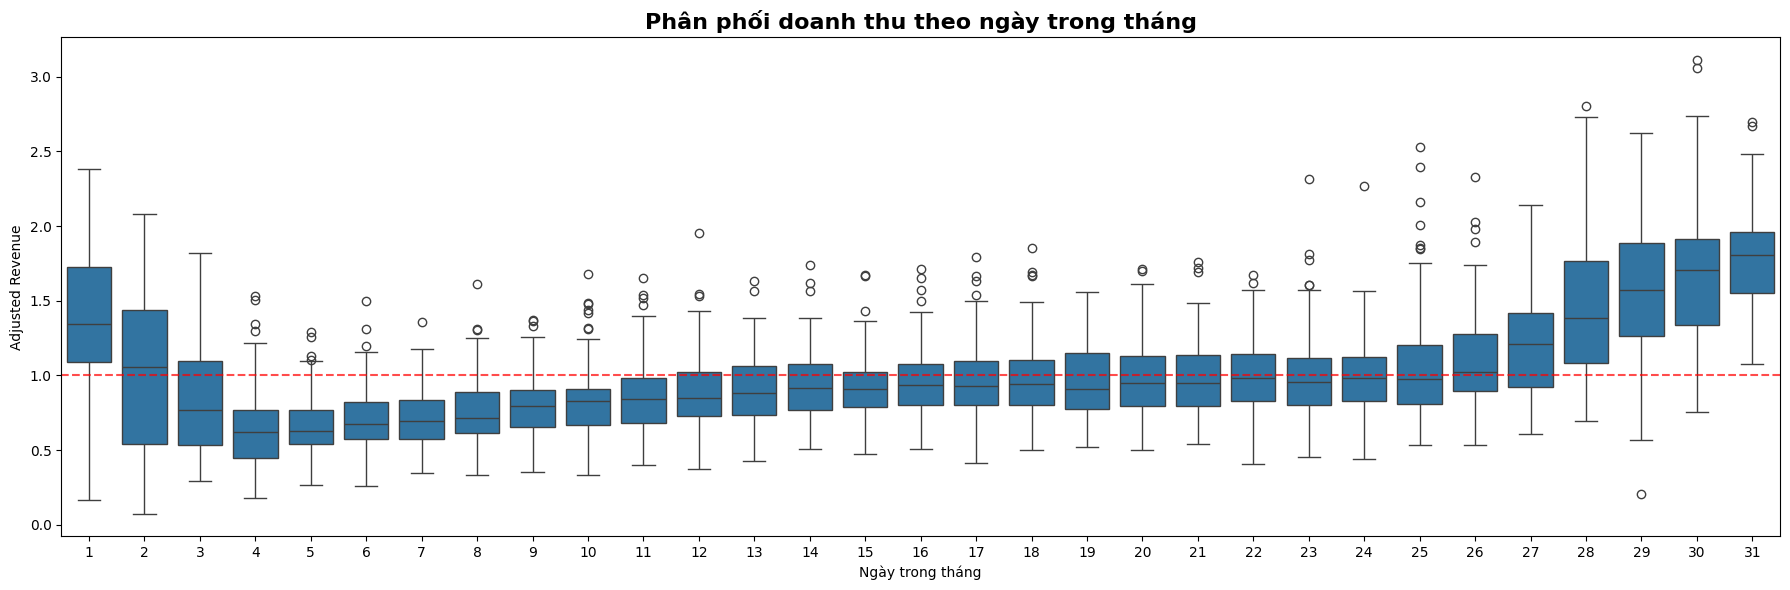

In [15]:
# Phân phối doanh thu theo ngày trong tháng
plt.figure(figsize=(18,6))

sns.boxplot(
    data=df,
    x='day_of_month',
    y='adj_revenue'
)

plt.axhline(1.0, linestyle='--', color='red', alpha=0.7)

plt.title(
    'Phân phối doanh thu theo ngày trong tháng',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Ngày trong tháng')
plt.ylabel('Adjusted Revenue')
plt.tight_layout()
plt.show()

In [16]:
# Top 5 ngày mạnh nhất và yếu nhất
top_5 = daily_stats.nlargest(5, 'mean_adj')
bottom_5 = daily_stats.nsmallest(5, 'mean_adj')

print("="*60)
print("PHÂN TÍCH MÙA VỤ TRONG THÁNG")
print("="*60)

print("\nTOP 5 NGÀY CAO NHẤT:")
for _, row in top_5.iterrows():
    print(f"Ngày {int(row['day_of_month']):02d}: +{row['seasonal_pct']:.2f}% | Số quan sát = {int(row['n_obs'])}")

print("\nTOP 5 NGÀY THẤP NHẤT:")
for _, row in bottom_5.iterrows():
    print(f"Ngày {int(row['day_of_month']):02d}: {row['seasonal_pct']:.2f}% | Số quan sát = {int(row['n_obs'])}")

# Kiểm định Kruskal-Wallis để xem sự khác biệt giữa các ngày trong tháng có ý nghĩa thống kê không
groups = [
    group['adj_revenue'].values
    for _, group in df.groupby('day_of_month')
]

stat, p_value = stats.kruskal(*groups)

print("\nKIỂM ĐỊNH KRUSKAL-WALLIS")
print("-"*60)
print(f"Statistic = {stat:.4f}")
print(f"P-value   = {p_value:.6f}")

if p_value < 0.05:
    print("KẾT LUẬN: Tồn tại tính mùa vụ nội tháng rõ rệt")
else:
    print("KẾT LUẬN: Chưa đủ bằng chứng thống kê để khẳng định")

PHÂN TÍCH MÙA VỤ TRONG THÁNG

TOP 5 NGÀY CAO NHẤT:
Ngày 31: +80.05% | Số quan sát = 74
Ngày 30: +68.08% | Số quan sát = 116
Ngày 29: +58.54% | Số quan sát = 118
Ngày 28: +45.09% | Số quan sát = 126
Ngày 01: +40.02% | Số quan sát = 125

TOP 5 NGÀY THẤP NHẤT:
Ngày 04: -36.45% | Số quan sát = 125
Ngày 05: -34.04% | Số quan sát = 125
Ngày 06: -30.07% | Số quan sát = 125
Ngày 07: -28.74% | Số quan sát = 125
Ngày 08: -24.57% | Số quan sát = 125

KIỂM ĐỊNH KRUSKAL-WALLIS
------------------------------------------------------------
Statistic = 1433.5917
P-value   = 0.000000
KẾT LUẬN: Tồn tại tính mùa vụ nội tháng rõ rệt


**Nhận xét**:

Cũng giống như năm, tháng cũng có chu kỳ và còn rõ ràng hơn so với năm. Với đầu tháng và cuối tháng, thực tế 2 đoạn thời gian này là thời gian các khách hàng được trả lương, vì vậy sẽ cao hơn so với mấy ngày còn lại. còn bắt đầu từ ngày 3 trở đi, doanh nghiệp đạt độ sâu nhất rồi răng dần trở lại cho đến cuối tháng.

Các features tốt nhất:
- `day_of_month`: Các ngày trong tháng
- `intra_month_index`: Hệ số kỳ vọng theo ngày (tính từ bước detrending EDA)
- `is_payday_spike`: Cờ nhị phân (1/0). Bằng 1 cho nhóm "Ngày hốt bạc" (Ngày 27 đến 31 và mùng 1). Kích hoạt dự báo tăng vọt.
- `is_post_bill_slump`: Cờ nhị phân (1/0). Bằng 1 cho nhóm "Ngày ế ẩm" (Ngày 4 đến ngày 8). Kéo dự báo xuống thấp.

### 5.4 Mùa vụ theo Tuần

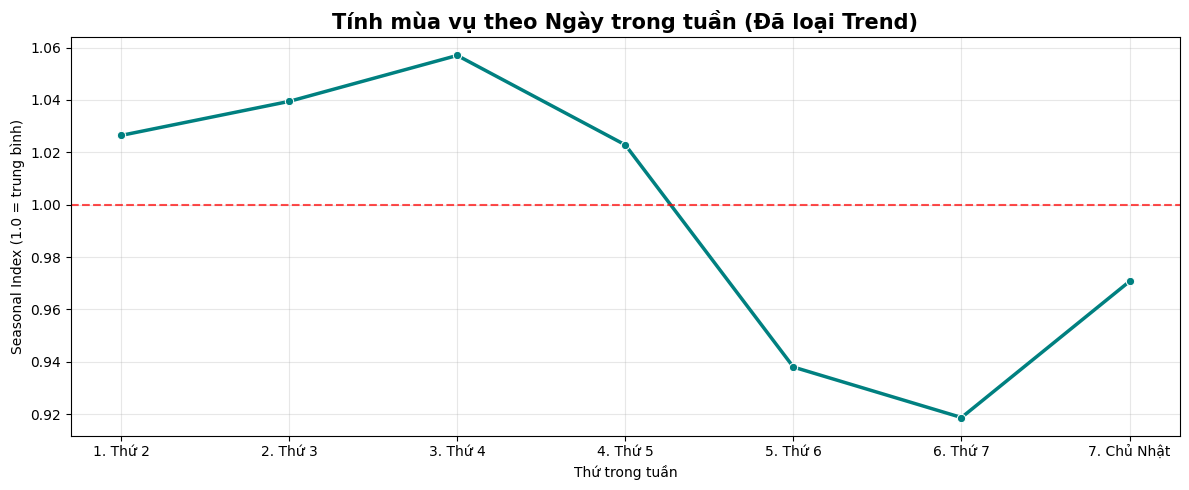

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_14892\2416345946.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='dow_name', y='adj_revenue', palette='Set2', showfliers=False)


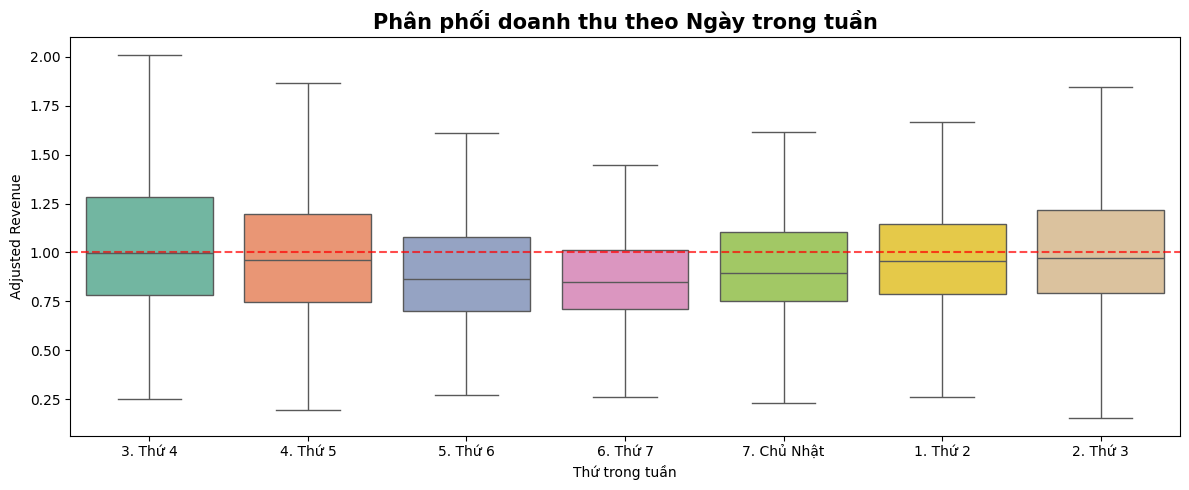

PHÂN TÍCH MÙA VỤ THEO TUẦN (DAY-OF-WEEK)
1. Thứ 2: Tăng 2.64% (Obs: 547)
2. Thứ 3: Tăng 3.95% (Obs: 547)
3. Thứ 4: Tăng 5.70% (Obs: 548)
4. Thứ 5: Tăng 2.28% (Obs: 548)
5. Thứ 6: Giảm 6.20% (Obs: 548)
6. Thứ 7: Giảm 8.13% (Obs: 548)
7. Chủ Nhật: Giảm 2.93% (Obs: 547)

KIỂM ĐỊNH KRUSKAL-WALLIS
--------------------------------------------------
P-value   = 0.000000
=> KẾT LUẬN: P-value < 0.05. Tồn tại hiệu ứng Ngày trong tuần cực kỳ rõ rệt.


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ==================================================
# KIỂM TRA TÍNH MÙA VỤ THEO TUẦN (DAY-OF-WEEK)
# ==================================================

# Copy dữ liệu để tránh sửa gốc
df = df_sales.copy() # Đổi thành tên dataframe chứa 'revenue' của bạn

# 1. Chuẩn hóa dữ liệu
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Lấy Ngày trong tuần (0 = Thứ 2, 6 = Chủ Nhật)
df['day_of_week'] = df['date'].dt.dayofweek

# Map số thành tên cho dễ nhìn
dow_mapping = {
    0: '1. Thứ 2', 1: '2. Thứ 3', 2: '3. Thứ 4', 
    3: '4. Thứ 5', 4: '5. Thứ 6', 5: '6. Thứ 7', 6: '7. Chủ Nhật'
}
df['dow_name'] = df['day_of_week'].map(dow_mapping)

# 2. Xử lý trend dài hạn (Detrend) - Thêm center=True như đã bàn
df['trend_30'] = df['revenue'].rolling(window=30, min_periods=7, center=True).mean()
df['adj_revenue'] = df['revenue'] / df['trend_30']
df = df.dropna(subset=['adj_revenue'])

# 3. Tính thống kê theo Thứ
weekly_stats = df.groupby('dow_name').agg(
    mean_adj=('adj_revenue', 'mean'),
    median_adj=('adj_revenue', 'median'),
    n_obs=('adj_revenue', 'count')
).reset_index()

weekly_stats['seasonal_pct'] = (weekly_stats['mean_adj'] - 1) * 100

# 4. VISUALIZATION #1 - Line Plot
plt.figure(figsize=(12, 5))
sns.lineplot(data=weekly_stats, x='dow_name', y='mean_adj', marker='o', linewidth=2.5, color='teal')
plt.axhline(1.0, linestyle='--', color='red', alpha=0.7)
plt.title('Tính mùa vụ theo Ngày trong tuần (Đã loại Trend)', fontsize=15, fontweight='bold')
plt.xlabel('Thứ trong tuần')
plt.ylabel('Seasonal Index (1.0 = trung bình)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 5. VISUALIZATION #2 - Boxplot (Đã ẩn Outliers)
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='dow_name', y='adj_revenue', palette='Set2', showfliers=False)
plt.axhline(1.0, linestyle='--', color='red', alpha=0.7)
plt.title('Phân phối doanh thu theo Ngày trong tuần', fontsize=15, fontweight='bold')
plt.xlabel('Thứ trong tuần')
plt.ylabel('Adjusted Revenue')
plt.tight_layout()
plt.show()

# 6. IN KẾT QUẢ PHÂN TÍCH
print("="*50)
print("PHÂN TÍCH MÙA VỤ THEO TUẦN (DAY-OF-WEEK)")
print("="*50)

for _, row in weekly_stats.iterrows():
    status = "Tăng" if row['seasonal_pct'] > 0 else "Giảm"
    print(f"{row['dow_name']}: {status} {abs(row['seasonal_pct']):.2f}% (Obs: {row['n_obs']})")

# 7. Kiểm định Kruskal-Wallis
groups = [group['adj_revenue'].values for _, group in df.groupby('dow_name')]
stat, p_value = stats.kruskal(*groups)

print("\nKIỂM ĐỊNH KRUSKAL-WALLIS")
print("-" * 50)
print(f"P-value   = {p_value:.6f}")

if p_value < 0.05:
    print("=> KẾT LUẬN: P-value < 0.05. Tồn tại hiệu ứng Ngày trong tuần cực kỳ rõ rệt.")
else:
    print("=> KẾT LUẬN: P-value >= 0.05. Khách hàng mua sắm đều đặn các ngày, không phân biệt cuối tuần hay ngày thường.")

**Nhận xét**:

Kết quả thu được là dữ liệu cũng có tính mùa vụ theo tuần. Điều này là cực kỳ hữu ích để dự đoán từng biến động nhỏ trong mô hình. Ngoài ra, chúng ta cũng có thể thấy rằng thói quen của khách hàng sẽ tập trung vào các ngày trong tuần nhiều hơn so với là cuối tuần

Các features tốt nhất:
- `revenue_lag_7`: Doanh thu của đúng thứ này tuần trước.
- `day_of_week`: Các ngày trong tuần
- `day_of_week_index`: Hệ số kỳ vọng
- `is_weekend`: Cờ nhị phân. Bằng 1 cho thứ bảy và chủ nhật

## 6. Tổng kết
Sau khi có toàn bộ features tốt nhất được lấy dựa trên tính mùa vụ, chúng tôi sẽ tạo thêm một file dữ liệu để lưu lại toàn bộ những gì đã tìm thấy, sau đó bước tiếp theo của chúng tôi sẽ triển khai kỹ thuật `features engineering` để thêm hoặc lọc bớt các features.

In [18]:
# Các biến thời gian cơ bản
import pandas as pd
import numpy as np

# Đảm bảo date đúng định dạng và sắp xếp tăng dần
df_sales['date'] = pd.to_datetime(df_sales['date'])
df_sales = df_sales.sort_values('date').reset_index(drop=True)

# 1. Các biến thời gian cơ bản
df_sales['month'] = df_sales['date'].dt.month
df_sales['day_of_month'] = df_sales['date'].dt.day
df_sales['day_of_week'] = df_sales['date'].dt.dayofweek # 0=Thứ 2, 6=Chủ Nhật

print("Đã tạo các biến thời gian cơ bản: month, day_of_month, day_of_week")

Đã tạo các biến thời gian cơ bản: month, day_of_month, day_of_week


In [19]:
# Các hệ số kỳ vọng
# 2. Ánh xạ Hệ số mùa vụ theo Năm (đã tính ở bước trước)
annual_seasonal_map = {
    1: 0.603, 2: 0.749, 3: 1.185, 4: 1.493, 5: 1.550, 6: 1.463, 
    7: 1.115, 8: 1.028, 9: 0.868, 10: 0.783, 11: 0.590, 12: 0.574
}
df_sales['seasonal_index'] = df_sales['month'].map(annual_seasonal_map)

# 3. Ánh xạ Hệ số kỳ vọng theo Tuần (lấy từ kết quả EDA gần nhất)
weekly_seasonal_map = {
    0: 1.026, 1: 1.039, 2: 1.057, 3: 1.023, 4: 0.938, 5: 0.918, 6: 0.971
}
df_sales['day_of_week_index'] = df_sales['day_of_week'].map(weekly_seasonal_map)

# 4. Hệ số kỳ vọng theo Ngày trong tháng (Ví dụ mẫu từ EDA của bạn)
# Bạn có thể thay thế bằng bảng đầy đủ 31 ngày nếu muốn chính xác tuyệt đối
df_sales['intra_month_index'] = df_sales.groupby('day_of_month')['revenue'].transform(lambda x: x.mean() / df_sales['revenue'].mean())

print("Đã gắn các hệ số Seasonal Index thành công.")

Đã gắn các hệ số Seasonal Index thành công.


In [20]:
# Các cờ nhị phân cho các ngày đặc biệt
# 5. Cờ mùa cao điểm (Tháng 3 đến tháng 8)
df_sales['is_peak_season'] = df_sales['month'].between(3, 8).astype(int)

# 6. Cờ cuối tuần (Thứ 7 và Chủ Nhật)
df_sales['is_weekend'] = df_sales['day_of_week'].isin([5, 6]).astype(int)

# 7. Cờ "Ngày hốt bạc" (Payday: 27-31 và mùng 1)
df_sales['is_payday_spike'] = df_sales['day_of_month'].isin([27, 28, 29, 30, 31, 1]).astype(int)

# 8. Cờ "Ngày ế ẩm" (Hậu hóa đơn: 4-8)
df_sales['is_post_bill_slump'] = df_sales['day_of_month'].isin([4, 5, 6, 7, 8]).astype(int)

print("Đã tạo các cờ nhị phân: is_peak_season, is_weekend, is_payday_spike, is_post_bill_slump")

Đã tạo các cờ nhị phân: is_peak_season, is_weekend, is_payday_spike, is_post_bill_slump


In [21]:
# Tạo lag và rolling features
# 9. Nhóm biến Lag (Quá khứ xa)
df_sales['revenue_lag_7'] = df_sales['revenue'].shift(7)
df_sales['revenue_lag_364'] = df_sales['revenue'].shift(364)

# 10. Nhóm biến Rolling (Phong độ gần đây)
# Phải shift(1) để ngày hôm nay không được nhìn thấy doanh thu của chính nó
rev_prev = df_sales['revenue'].shift(1)

df_sales['revenue_rolling_mean_28'] = rev_prev.rolling(window=28, min_periods=7).mean()
df_sales['revenue_rolling_mean_90'] = rev_prev.rolling(window=90, min_periods=14).mean()

# 11. Momentum Ratio (Đà tăng trưởng)
df_sales['momentum_ratio'] = df_sales['revenue_rolling_mean_28'] / df_sales['revenue_rolling_mean_90']

# Xử lý giá trị vô cùng nếu có (chia cho 0)
df_sales['momentum_ratio'] = df_sales['momentum_ratio'].replace([np.inf, -np.inf], 1.0).fillna(1.0)

print("Hoàn tất tạo biến Lag, Rolling và Momentum.")

Hoàn tất tạo biến Lag, Rolling và Momentum.


In [22]:
df_sales.head()

,date,revenue,cogs,month,day_of_month,day_of_week,seasonal_index,day_of_week_index,intra_month_index,is_peak_season,is_weekend,is_payday_spike,is_post_bill_slump,revenue_lag_7,revenue_lag_364,revenue_rolling_mean_28,revenue_rolling_mean_90,momentum_ratio
0,2012-07-04,5123547.94,3982991.19,7,4,2,1.115,1.057,0.626209,1,0,0,1,NaN,NaN,NaN,NaN,1.0
1,2012-07-05,2751773.45,2150580.23,7,5,3,1.115,1.023,0.641836,1,0,0,1,NaN,NaN,NaN,NaN,1.0
2,2012-07-06,3054029.42,2517632.84,7,6,4,1.115,0.938,0.677476,1,0,0,1,NaN,NaN,NaN,NaN,1.0
3,2012-07-07,2667930.94,2108246.62,7,7,5,1.115,0.918,0.696571,1,1,0,1,NaN,NaN,NaN,NaN,1.0
4,2012-07-08,2360851.90,1808622.79,7,8,6,1.115,0.971,0.730281,1,1,0,1,NaN,NaN,NaN,NaN,1.0


In [23]:
from src.save_data import save_to_processed
save_to_processed(df_sales, 'sales_seasonal.csv')

Đã lưu thành công tại: D:\datathon\vimchanhxa-datathon\data\processed\sales_seasonal.csv


---
**Kết luận:**

---
**Notebooks tiếp theo:** [03_METHODS_.ipynb](03_METHODS) - Những phương pháp huấn luyện mô hình